In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn pyspellchecker

  Using cached pyspellchecker-0.8.2-py3-none-any.whl (7.1 MB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Joshua\amdira-projects\fraud-detection\fraud-venv\Scripts\python.exe -m pip install --upgrade pip' command.


Nova Credit fraudulent Transaction Detection for Digital Money Transfer:

This Project aims to strengthen Novas transaction security process by detecting fraudulent transactions at the point of transaction processing. 

This project will develop a machine-learning model that provides fast, data-driven fraud predictions to support accurate detection, regulatory compliance, and improved customer experience.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mp
import seaborn as sn

# Load the dataset
data_path = r'C:\Users\Joshua\amdira-projects\fraud-detection\data\nova_pay_combined.csv'
data = pd.read_csv(data_path)


In [23]:
# Explore the dataset
data.head() 


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [24]:
# explore the dataset the last 5 rows
data.tail()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
11395,b5ef3323-46d2-4f6c-9c19-43df4e55df48,8734e6a7-f34e-49f2-b559-1d62a756664c,2025-11-25 10:05:35.573611+00:00,US,USD,CAD,mobile,271.25,271.25,5.24,...,0.307,standard,742,0.653,0,0.302,1,2,0.00,0
11396,54f00f78-94aa-4a08-bf6b-12877aa47186,c18070a6-bdb9-4df3-9df7-5d92c0bff424,2025-11-26 07:09:56.573611+00:00,CA,CAD,NGN,web,537.17,397.51,8.86,...,0.891,low,9,0.173,2,0.730,3,6,0.00,1
11397,6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5,2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca,2025-11-27 06:19:11.573611+00:00,CA,CAD,INR,web,205.15,151.81,4.00,...,1.000,low,21,0.269,1,0.605,3,4,0.12,1
11398,4aad7389-2b62-4885-a23e-aa3ecd5cfaf9,8b1cf558-4ed7-48ee-b330-75db6efd4840,2025-11-28 00:53:28.573611+00:00,US,USD,PHP,mobile,78.03,78.03,1.96,...,0.298,enhanced,471,0.773,0,0.375,0,2,0.00,0
11399,fdffeb16-192a-4483-9b1e-9928e23269c2,b69010dc-ab0a-4fd2-a79e-65e4c6efbcd9,2025-11-29 20:10:47.573611+00:00,US,USD,NGN,web,1214.16,1214.16,19.34,...,1.000,low,58,0.187,0,0.646,4,6,0.25,1


In [25]:
# explore the datatypes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

In [27]:
# Lets count missing values in the dataset
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64


In [28]:
# lets summary statistics of the dataset    
data.describe()

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11095.000000,11105.000000,11400.000000,11400.000000,11400.000000,11105.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000
mean,452.022083,100.309441,167.540397,0.396726,393.793158,0.653681,0.048509,0.267134,0.458333,0.723509,0.045501,0.087456
std,1403.973062,958.128504,382.023827,0.270507,342.348393,0.273012,0.256194,0.142983,1.524494,1.958390,0.084942,0.282515
min,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,92.465000,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,163.480000,3.500000,7.142857,0.325000,298.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,302.190000,5.550000,73.529412,0.487000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [32]:
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)
data[data.duplicated(keep=False)]  # Display duplicate rows

Number of duplicate rows: 200


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
57,4662cb2d-21b2-4390-ba38-5a1eddebdc7c,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-09 20:21:25.468549+00:00,US,USD,GBP,mobile,152.75,152.75,3.35,...,0.328,standard,263,0.522,0,0.223,5,5,0.00,0
83,e69d481f-2ee3-4621-a58a-73fec8c63eca,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-13 03:17:46.468549+00:00,US,USD,CNY,ATM,385.27,385.27,7.05,...,0.458,enhanced,367,0.939,0,0.176,0,0,0.00,0
178,8537371a-7eae-4108-89c9-5660e5025a88,d71c91b4-fee8-4104-9856-a5c6109a62e3,2022-10-23 16:36:46.468549+00:00,US,USD,MXN,web,86.6,86.60,1.96,...,0.342,standard,298,0.336,0,0.166,0,0,0.20,0
245,2e553c23-063e-4b5e-aa2e-8a41d6aa61ca,0f5daa28-9086-4c15-8379-eb7a440393c7,2022-10-30 19:05:06.468549+00:00,UK,GBP,EUR,web,165.39,206.73,4.07,...,0.200,standard,281,0.704,0,0.522,0,0,0.05,0
352,a9198fb0-d831-48df-b434-c30a39078aa3,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-11-13 04:59:47.468549+00:00,US,USD,CNY,web,85.68,85.68,1.91,...,0.601,standard,263,0.522,0,0.223,0,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10195,a5c6391d-4763-4ed6-a5ef-80b744cf71b2,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-11-25 16:25:46.468549+00:00,US,USD,GBP,mobile,127.91,127.91,2.97,...,0.315,standard,1018,0.934,0,0.087,0,0,0.00,0
10196,35c133e7-7279-4d24-ac0e-967675f2c2a0,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2023-01-13 16:50:48.468549+00:00,US,USD,CNY,ATM,286.59,286.59,5.12,...,0.383,enhanced,257,0.894,0,0.257,0,0,0.00,0
10197,6263d697-0900-440c-99d7-b4be90e733b5,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2025-07-02 11:33:48.468549+00:00,US,USD,USD,mobile,230.09,230.09,4.01,...,0.244,enhanced,367,0.939,0,0.176,0,0,0.00,0
10198,883403f5-fd2f-4b39-824e-9710485a983e,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2023-01-01 02:40:14.468549+00:00,UK,GBP,PHP,mobile,-168.96,211.20,9999.99,...,1.200,standard,4,-0.100,0,0.407,-1,0,0.00,0


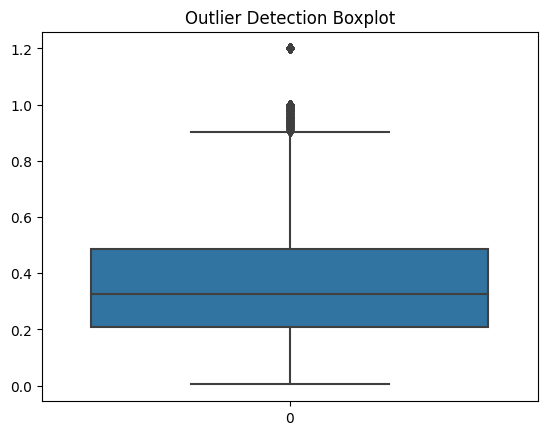

In [38]:
# check for outliers in the dataset using boxplots
sn.boxplot(data=data['ip_risk_score'])
mp.title('Outlier Detection Boxplot')
mp.show()

In [6]:
# Find misspelled values in categorical text columns
import re
from spellchecker import SpellChecker

spell = SpellChecker()
known_terms = [
    "US", "UK", "CA", "USD", "GBP", "CAD", "EUR", "MXN", "NGN",
    "INR", "CNY", "PHP", "ATM", "KYC", "unknown", "nan",
    "mobile", "web", "standard", "enhanced", "low"
]
spell.word_frequency.load_words(known_terms)

categorical_columns = [
    column for column in data.select_dtypes(include=["object", "string"]).columns
    if data[column].nunique(dropna=True) <= 100
]
incorrect_values_by_column = {}

for column in categorical_columns:
    incorrect_values = []
    for value in data[column].dropna().unique():
        words = re.findall(r"[A-Za-z]+", str(value))
        if spell.unknown(words):
            incorrect_values.append(value)
    if incorrect_values:
        incorrect_values_by_column[column] = incorrect_values

if incorrect_values_by_column:
    display(pd.DataFrame({
        column: pd.Series(values)
        for column, values in incorrect_values_by_column.items()
    }))
else:
    print("No misspelled values found.")

,channel,kyc_tier
0,mobille,standrd
1,weeb,enhancd


In [ ]:
# Find values that cannot be parsed as numbers
numeric_columns = set(data.select_dtypes(include=["number"]).columns)

for column in data.select_dtypes(include=["object", "string"]).columns:
    non_missing_values = data[column].dropna()
    if not non_missing_values.empty:
        parsed_values = pd.to_numeric(non_missing_values, errors="coerce")
        if parsed_values.notna().mean() >= 0.9:
            numeric_columns.add(column)

invalid_number_values = []
for column in sorted(numeric_columns):
    invalid_values = data.loc[
        data[column].notna()
        & pd.to_numeric(data[column], errors="coerce").isna(),
        column
    ].value_counts()
    for value, count in invalid_values.items():
        invalid_number_values.append({
            "column": column,
            "value that will not parse": value,
            "count": count
        })

if invalid_number_values:
    display(pd.DataFrame(invalid_number_values))
else:
    print("All values in numeric columns parse as numbers.")

,column,value that will not parse,count
0,amount_src,"9,998.85",1
1,amount_src,"9,995.95",1
2,amount_src,"1,541.55",1
3,amount_src,"9,991.24",1
